## Charger le split déja crée dans 'clustering_stratifie.ipynb' 

In [2]:

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb


ROOT = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / "data" / "processed"

X = pd.read_parquet(DATA_PROCESSED / "X.parquet")
Y = pd.read_parquet(DATA_PROCESSED / "Y.parquet")

idx_train = np.load(DATA_PROCESSED / "idx_train.npy")
idx_test  = np.load(DATA_PROCESSED / "idx_test.npy")

X_train = X.iloc[idx_train]
X_test  = X.iloc[idx_test]

Y_train = Y.iloc[idx_train]
Y_test  = Y.iloc[idx_test]

print(X_train.shape, X_test.shape)



(439976, 110) (109995, 110)


## Créer un validation set
#### On conserve la meme stratification en utilisant 'stratum-final'

In [3]:


labels = pd.read_parquet(
    DATA_PROCESSED / "cluster_labels.parquet"
)

stratum_train = labels.iloc[idx_train]["stratum_final"]

X_train_final, X_val, Y_train_final, Y_val, strat_train, strat_val = train_test_split(
    X_train,
    Y_train,
    stratum_train,
    test_size=0.2,
    random_state=42,
    stratify=stratum_train
)


total = len(X_train_final) + len(X_val) + len(X_test)

print(f"Train : {X_train_final.shape} ({len(X_train_final)/total:.1%})")
print(f"Val   : {X_val.shape} ({len(X_val)/total:.1%})")
print(f"Test  : {X_test.shape} ({len(X_test)/total:.1%})")



Train : (351980, 110) (64.0%)
Val   : (87996, 110) (16.0%)
Test  : (109995, 110) (20.0%)


## Baseline naive

In [4]:
results_dummy = {}

print("===== Baseline naïve (médiane) par cible =====\n")

for target in Y.columns:

    # prédiction naïve = médiane du train
    median_value = Y_train_final[target].median()
    y_pred = np.full(len(Y_test), median_value)

    # métriques
    rmse = np.sqrt(mean_squared_error(Y_test[target], y_pred))
    mae  = mean_absolute_error(Y_test[target], y_pred)
    r2   = r2_score(Y_test[target], y_pred)

    results_dummy[target] = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

    print(f"{target}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAE  = {mae:.2f}")
    print(f"  R²   = {r2:.4f}\n")


===== Baseline naïve (médiane) par cible =====

out.electricity.total.energy_consumption..kwh
  RMSE = 8809.83
  MAE  = 5966.36
  R²   = -0.0568

out.natural_gas.total.energy_consumption..kwh
  RMSE = 18181.37
  MAE  = 10319.81
  R²   = -0.2563

out.fuel_oil.total.energy_consumption..kwh
  RMSE = 7089.03
  MAE  = 1259.82
  R²   = -0.0326

out.propane.total.energy_consumption..kwh
  RMSE = 6294.01
  MAE  = 1114.30
  R²   = -0.0324

out.emissions.total.lrmer_mid_case_25..co2e_kg
  RMSE = 4617.80
  MAE  = 3239.35
  R²   = -0.0722



# Entraînement multi-cibles LightGBM et sauvegarde des modèles

Chaque cible énergétique est entraînée indépendamment avec un modèle LightGBM.
Les modèles et leurs prédictions sont conservés afin de permettre l'analyse des performances,
la visualisation des prédictions et l'étude de l'importance des variables.


## Definition et entrainemant du modèle lightgbm 

In [5]:
results = {}
models = {}
predictions = {}

for target in Y.columns:

    print(f"\n========== {target} ==========")

    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=63,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_final,
        Y_train_final[target],
        eval_set=[(X_val, Y_val[target])],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    models[target] = model

    pred_train = model.predict(X_train_final)
    pred_val   = model.predict(X_val)
    pred_test  = model.predict(X_test)

    # Sauvegarde des prédictions test pour plus tard
    predictions[target] = pred_test

    # Métriques
    results[target] = {
        "Train_RMSE": np.sqrt(mean_squared_error(Y_train_final[target], pred_train)),
        "Train_MAE": mean_absolute_error(Y_train_final[target], pred_train),
        "Train_R2": r2_score(Y_train_final[target], pred_train),

        "Val_RMSE": np.sqrt(mean_squared_error(Y_val[target], pred_val)),
        "Val_MAE": mean_absolute_error(Y_val[target], pred_val),
        "Val_R2": r2_score(Y_val[target], pred_val),

        "Test_RMSE": np.sqrt(mean_squared_error(Y_test[target], pred_test)),
        "Test_MAE": mean_absolute_error(Y_test[target], pred_test),
        "Test_R2": r2_score(Y_test[target], pred_test)
    }

# Tableau récapitulatif
df_results = pd.DataFrame(results).T

# Tri 
df_results = df_results.sort_values("Test_R2", ascending=False)

print("\n===== Résultats =====")


df_results["Overfit_Gap"] = (
    df_results["Train_R2"] - df_results["Test_R2"]
)



display(df_results.round(4))




========== out.electricity.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 110
[LightGBM] [Info] Start training from score 11761.455661

========== out.natural_gas.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017776 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 110
[LightGBM] [Info] Start training from score 10593.506178

========== out.fuel_oil.total.energy_

,Train_RMSE,Train_MAE,Train_R2,Val_RMSE,Val_MAE,Val_R2,Test_RMSE,Test_MAE,Test_R2,Overfit_Gap
out.emissions.total.lrmer_mid_case_25..co2e_kg,1067.2842,639.6892,0.9436,1328.7835,722.8793,0.9124,1316.3715,722.9620,0.9129,0.0307
out.natural_gas.total.energy_consumption..kwh,4860.8387,2566.1214,0.9113,5861.3802,2918.0053,0.8701,5885.2433,2922.8741,0.8684,0.0429
out.electricity.total.energy_consumption..kwh,2745.2667,1497.5995,0.8988,3403.7000,1705.6411,0.8440,3392.8268,1709.4507,0.8433,0.0556
out.fuel_oil.total.energy_consumption..kwh,2900.6952,715.2653,0.8317,4239.9954,975.4125,0.6493,4058.4745,951.4719,0.6616,0.1701
out.propane.total.energy_consumption..kwh,3027.4280,858.3575,0.7587,4332.1163,1139.1309,0.5143,4382.6952,1150.1428,0.4994,0.2593


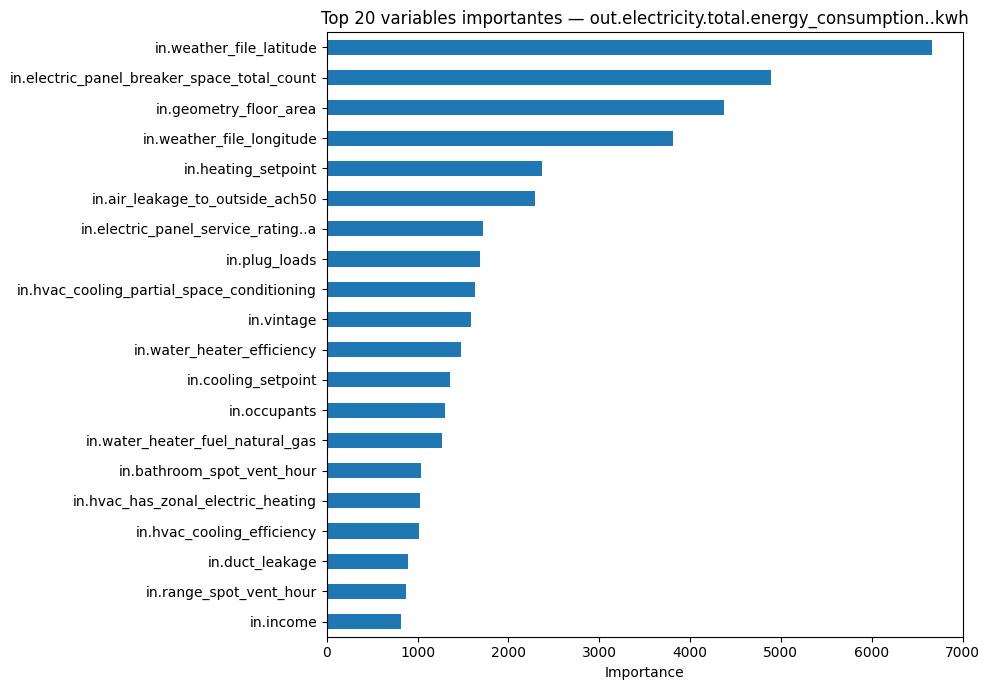

- Variable la plus importante : in.weather_file_latitude
- Contribution dominante : 15.84 %


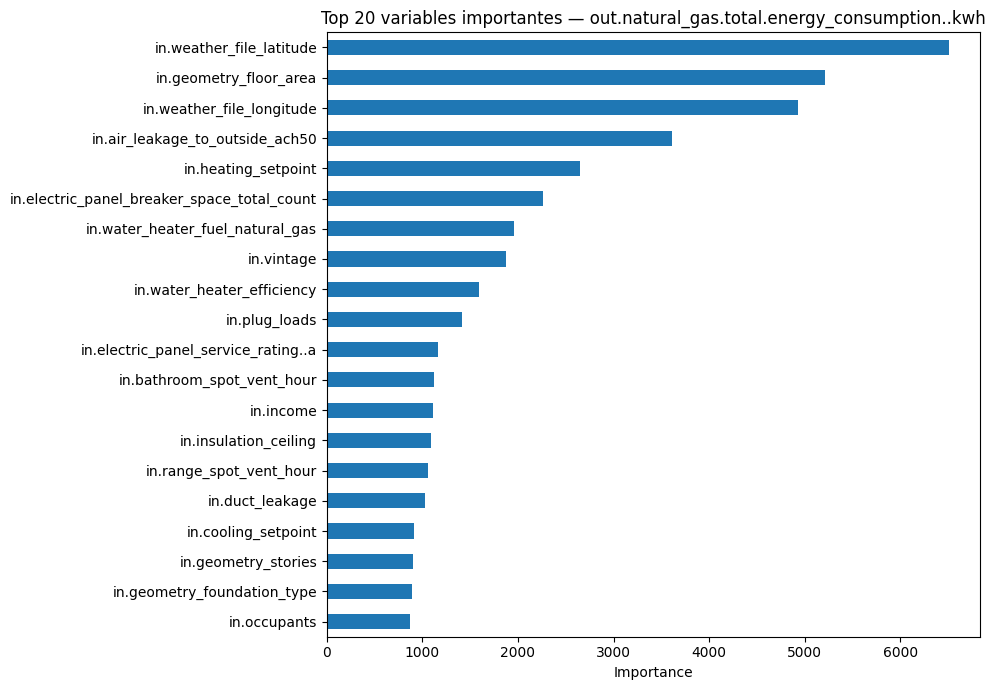

- Variable la plus importante : in.weather_file_latitude
- Contribution dominante : 15.44 %


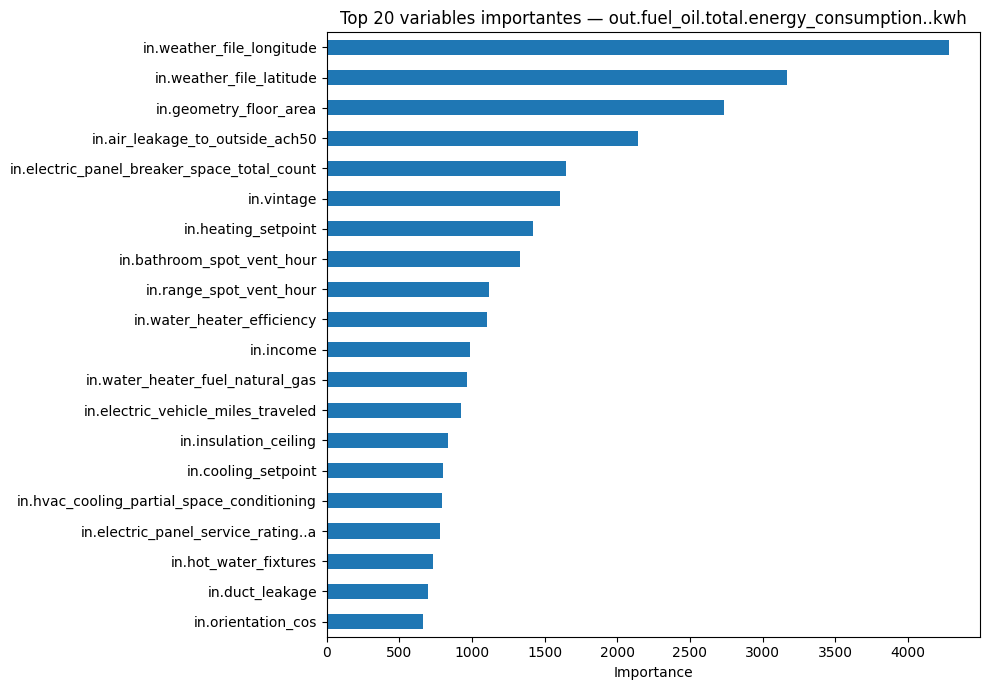

- Variable la plus importante : in.weather_file_longitude
- Contribution dominante : 14.91 %


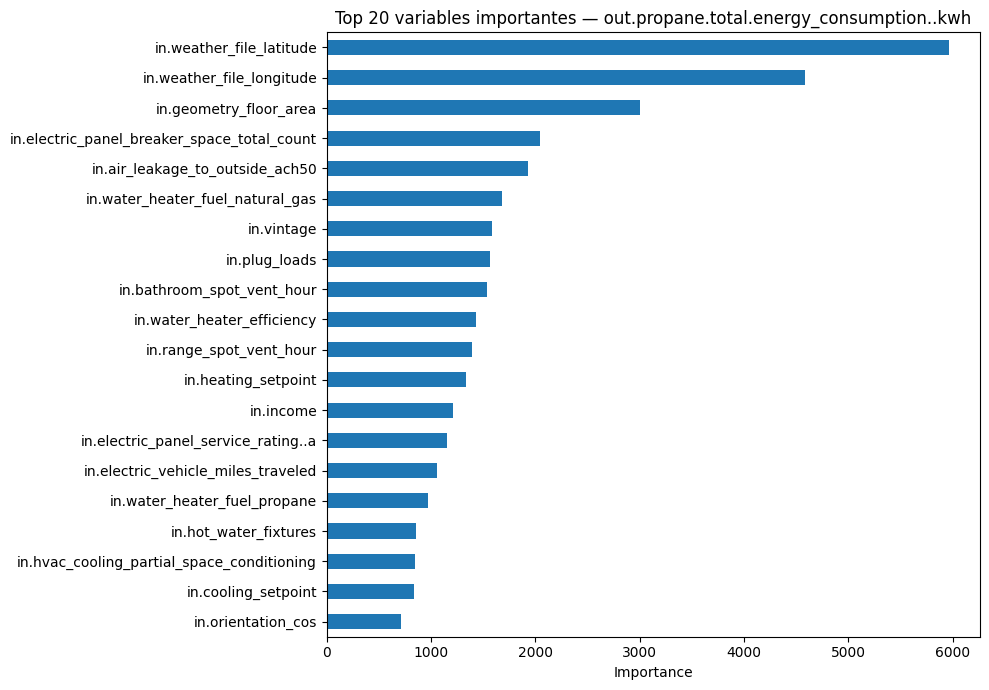

- Variable la plus importante : in.weather_file_latitude
- Contribution dominante : 16.7 %


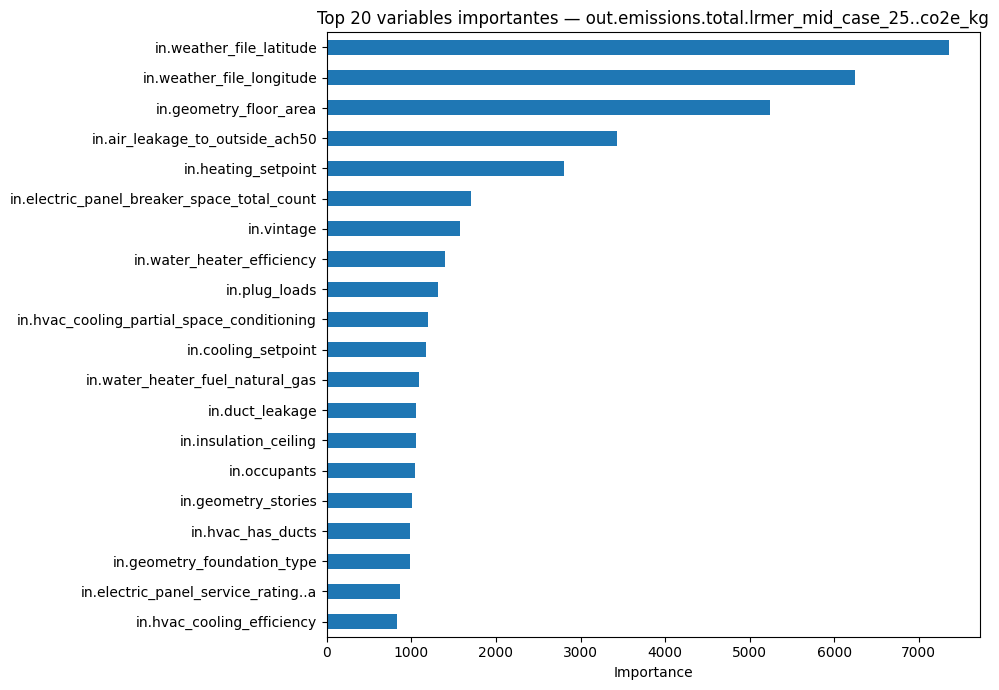

- Variable la plus importante : in.weather_file_latitude
- Contribution dominante : 17.37 %


In [15]:
for target in Y.columns:
    importance = pd.Series(
        models[target].feature_importances_,
        index=X_train_final.columns
    )

    top20 = importance.nlargest(20)

    plt.figure(figsize=(10,7))
    top20.sort_values().plot(kind="barh")

    plt.title(f"Top 20 variables importantes — {target}")
    plt.xlabel("Importance")
    plt.tight_layout()

    plt.show()
    print("- Variable la plus importante :", top20.index[0])
    print("- Contribution dominante :", round(top20.iloc[0] / top20.sum() * 100, 2), "%")



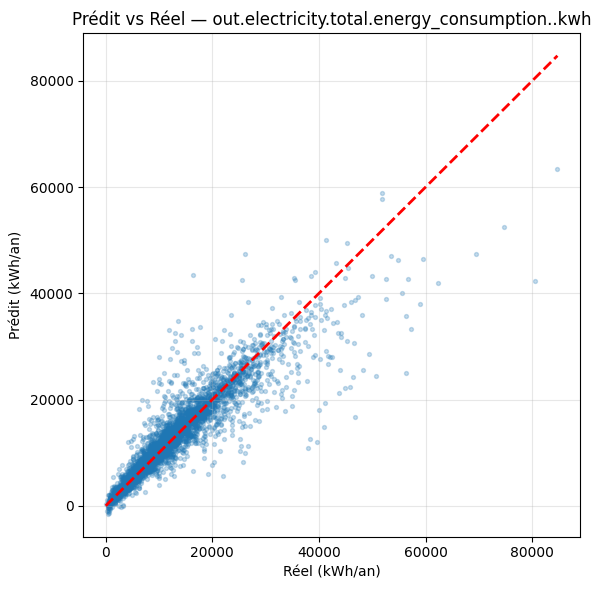

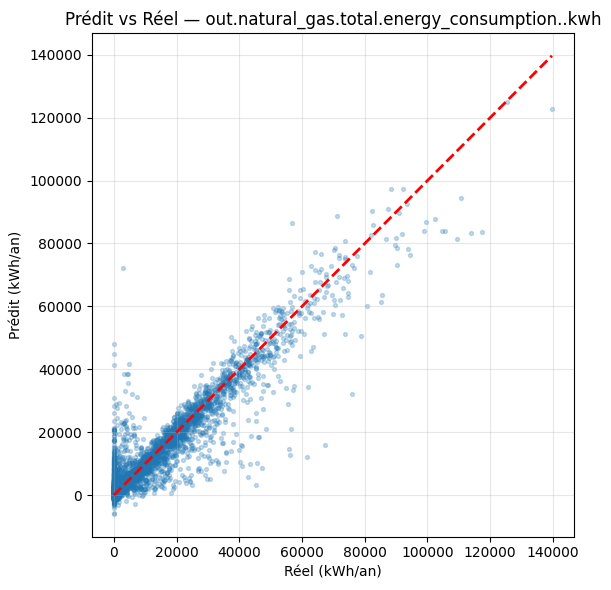

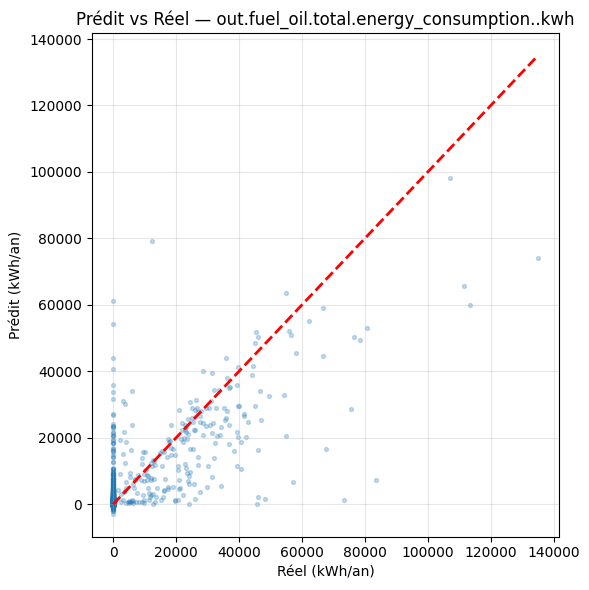

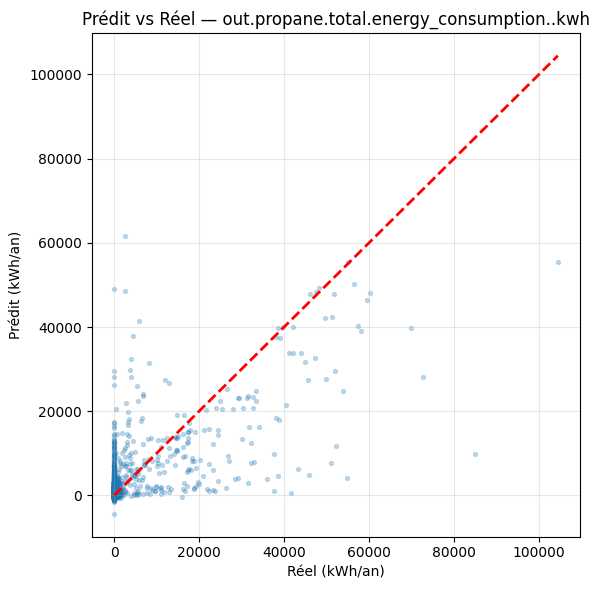

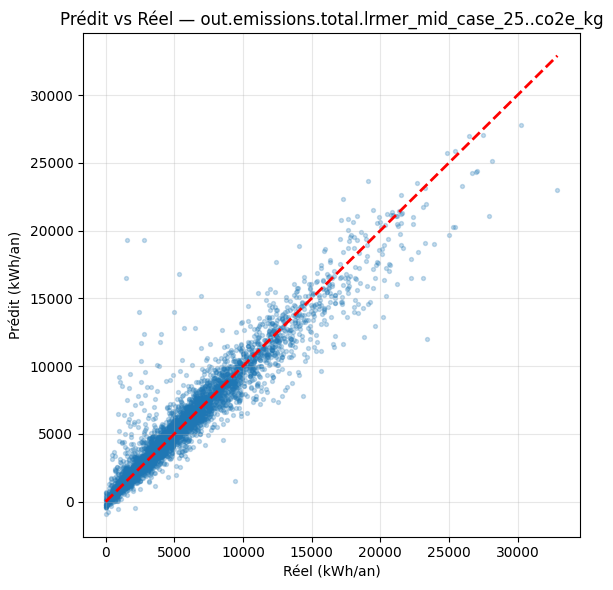

In [7]:

rng = np.random.default_rng(42)

n_points = 5000

for target in Y.columns:

    y_true = Y_test[target]
    y_pred = predictions[target]   

    n = min(n_points, len(y_true))

    sample = rng.choice(len(y_true), size=n, replace=False)

    y_true_sample = y_true.iloc[sample]
    y_pred_sample = y_pred[sample]

    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_true_sample,
        y_pred_sample,
        alpha=0.25,
        s=8
    )

    max_value = max(y_true_sample.max(), y_pred_sample.max())

    plt.plot(
        [0, max_value],
        [0, max_value],
        "r--",
        linewidth=2
    )

    plt.xlabel("Réel (kWh/an)")
    plt.ylabel("Prédit (kWh/an)")
    plt.title(f"Prédit vs Réel — {target}")

    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(f"pred_vs_real_{target}.png", dpi=300, bbox_inches="tight")  

    plt.show()


## Comparaison entre la baseline naïve et LightGBM

Afin d’évaluer la valeur ajoutée du modèle d’apprentissage, nous comparons les performances de LightGBM à une baseline naïve.

La baseline naïve consiste à prédire, pour chaque cible énergétique, la médiane observée dans le jeu d’entraînement.

Cette comparaison permet de quantifier le gain réel apporté par le modèle en termes de réduction d’erreur et d’explication de la variance (R²).


In [11]:
# Résultats Dummy
df_dummy = pd.DataFrame(results_dummy).T

# Résultats LightGBM (uniquement TEST)
df_lgbm = df_results[
    ["Test_RMSE", "Test_MAE", "Test_R2"]
].copy()

# Renommer pour être plus clair
df_dummy.columns = [
    "Dummy_RMSE",
    "Dummy_MAE",
    "Dummy_R2"
]

df_lgbm.columns = [
    "LGBM_RMSE",
    "LGBM_MAE",
    "LGBM_R2"
]

# Fusion
comparison = pd.concat(
    [df_dummy, df_lgbm],
    axis=1
)

# Calcul des gains
comparison["Gain_RMSE_%"] = (
    (comparison["Dummy_RMSE"] - comparison["LGBM_RMSE"])
    / comparison["Dummy_RMSE"]
    * 100
)

comparison["Gain_R2"] = (
    comparison["LGBM_R2"]
    - comparison["Dummy_R2"]
)

# Trier par amélioration du R²
comparison = comparison.sort_values(
    "Gain_R2",
    ascending=False
)

display(comparison.round(4))


,Dummy_RMSE,Dummy_MAE,Dummy_R2,LGBM_RMSE,LGBM_MAE,LGBM_R2,Gain_RMSE_%,Gain_R2
out.natural_gas.total.energy_consumption..kwh,18181.3705,10319.8101,-0.2563,5885.2433,2922.8741,0.8684,67.6304,1.1247
out.emissions.total.lrmer_mid_case_25..co2e_kg,4617.7951,3239.3536,-0.0722,1316.3715,722.9620,0.9129,71.4935,0.9850
out.electricity.total.energy_consumption..kwh,8809.8270,5966.3567,-0.0568,3392.8268,1709.4507,0.8433,61.4882,0.9000
out.fuel_oil.total.energy_consumption..kwh,7089.0346,1259.8168,-0.0326,4058.4745,951.4719,0.6616,42.7500,0.6942
out.propane.total.energy_consumption..kwh,6294.0131,1114.3018,-0.0324,4382.6952,1150.1428,0.4994,30.3672,0.5318


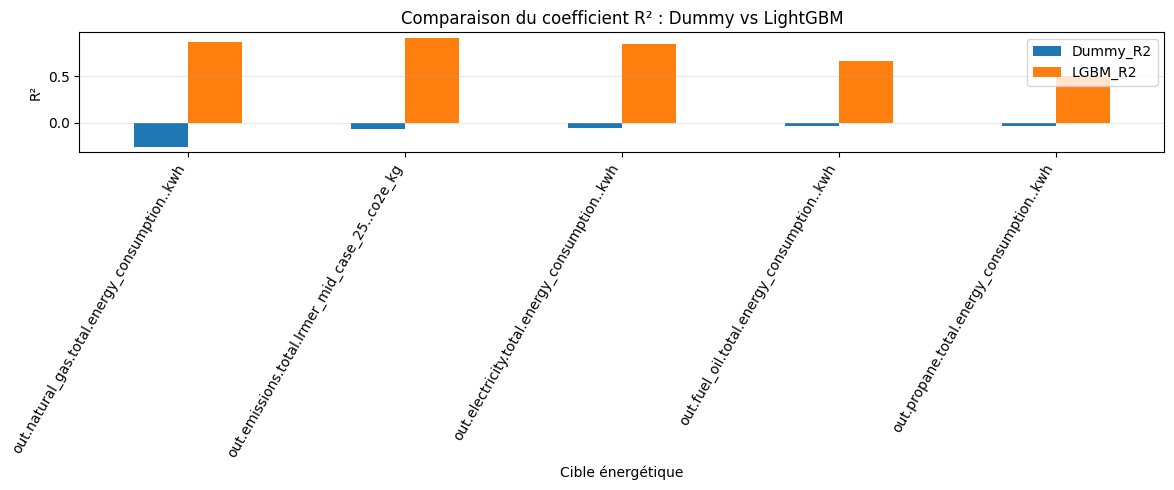

In [12]:
comparison[
    ["Dummy_R2", "LGBM_R2"]
].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title(
    "Comparaison du coefficient R² : Dummy vs LightGBM"
)

plt.ylabel("R²")
plt.xlabel("Cible énergétique")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "comparison_dummy_lightgbm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
